# Part D: CNN on MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)
np.random.seed(42)

#Data Preparation &amp; Baseline

In [2]:
from tensorflow.keras.datasets import mnist

(X_tr_full, y_tr_full), (X_te_full, y_te_full) = mnist.load_data()

X_train_c = X_tr_full[:12000] / 255.0
X_test_c  = X_te_full[:2000]  / 255.0
y_train_c = y_tr_full[:12000]
y_test_c  = y_te_full[:2000]

X_train_c = X_train_c.reshape(-1, 28, 28, 1)
X_test_c  = X_test_c.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


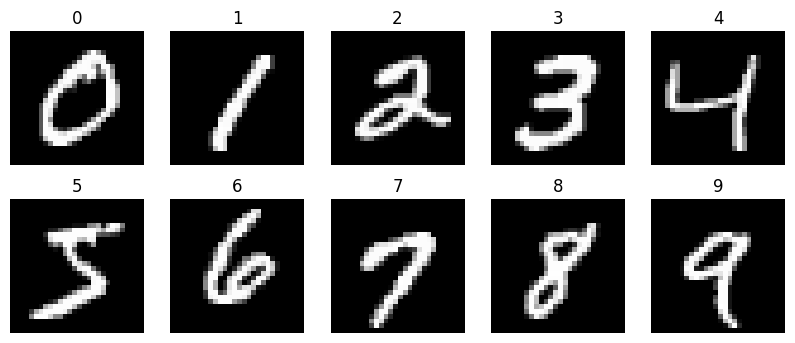

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    idx = np.where(y_train_c == digit)[0][0]
    ax  = axes[digit // 5][digit % 5]
    ax.imshow(X_train_c[idx].reshape(28, 28), cmap='gray')
    ax.set_title(str(digit))
    ax.axis('off')
plt.show()

In [4]:
mlp_baseline = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
mlp_baseline.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

mlp_baseline.fit(X_train_c, y_train_c, epochs=5,
                 validation_split=0.1, verbose=1)

_, baseline_acc = mlp_baseline.evaluate(X_test_c, y_test_c, verbose=0)
print("MLP Baseline Test Accuracy:", round(baseline_acc, 4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8521 - loss: 0.5611 - val_accuracy: 0.9083 - val_loss: 0.3437
Epoch 2/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9232 - loss: 0.2746 - val_accuracy: 0.9158 - val_loss: 0.2950
Epoch 3/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9386 - loss: 0.2177 - val_accuracy: 0.9233 - val_loss: 0.2647
Epoch 4/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9495 - loss: 0.1801 - val_accuracy: 0.9283 - val_loss: 0.2419
Epoch 5/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9586 - loss: 0.1517 - val_accuracy: 0.9342 - val_loss: 0.2285
MLP Baseline Test Accuracy: 0.9065


##Lightweight CNN

In [5]:
y_train_cat = to_categorical(y_train_c, 10)
y_test_cat  = to_categorical(y_test_c,  10)

datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1,width_shift_range=0.1, height_shift_range=0.1)
datagen.fit(X_train_c)

In [6]:
cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy', metrics=['accuracy'])

hist_cnn = cnn.fit(datagen.flow(X_train_c, y_train_cat, batch_size=64),
                   epochs=15,
                   validation_data=(X_test_c, y_test_cat),
                   verbose=1)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.6525 - loss: 1.0626 - val_accuracy: 0.9245 - val_loss: 0.2589
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.8670 - loss: 0.4318 - val_accuracy: 0.9470 - val_loss: 0.1706
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8988 - loss: 0.3255 - val_accuracy: 0.9520 - val_loss: 0.1336
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9118 - loss: 0.2793 - val_accuracy: 0.9585 - val_loss: 0.1257
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9271 - loss: 0.2372 - val_accuracy: 0.9640 - val_loss: 0.0992
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9352 - loss: 0.2130 - val_accuracy: 0.9645 - val_loss: 0.0987
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9389 - loss: 0.2036 - val_accuracy: 0.9685 - val_loss: 0.0978
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9425 - loss: 0.1879 - val_accuracy: 

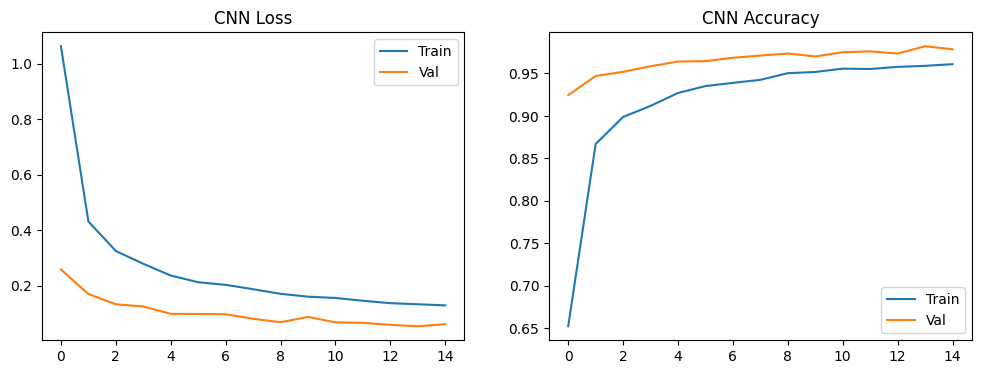

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_cnn.history['loss'],     label='Train')
ax1.plot(hist_cnn.history['val_loss'], label='Val')
ax1.set_title("CNN Loss")
ax1.legend()

ax2.plot(hist_cnn.history['accuracy'],     label='Train')
ax2.plot(hist_cnn.history['val_accuracy'], label='Val')
ax2.set_title("CNN Accuracy")
ax2.legend()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       175
           1       1.00      1.00      1.00       234
           2       0.98      0.99      0.98       219
           3       0.95      1.00      0.97       207
           4       0.98      0.98      0.98       217
           5       0.98      0.98      0.98       179
           6       0.98      0.99      0.99       178
           7       0.98      0.97      0.98       205
           8       0.97      0.96      0.96       192
           9       0.97      0.93      0.95       194

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



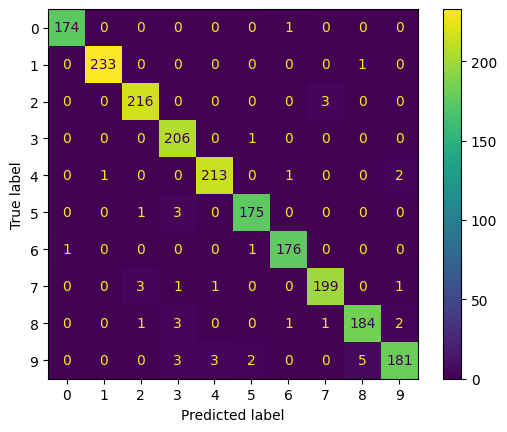

Most confused digit pair: (np.int64(9), np.int64(8))
Number of misclassifications: 5


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_prob_cnn = cnn.predict(X_test_c)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

print(classification_report(y_test_c, y_pred_cnn))

ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_cnn)
plt.show()

cm = confusion_matrix(y_test_c, y_pred_cnn)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

max_index = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print("Most confused digit pair:", max_index)
print("Number of misclassifications:", cm_no_diag[max_index])

#Visualising What the CNN Learned

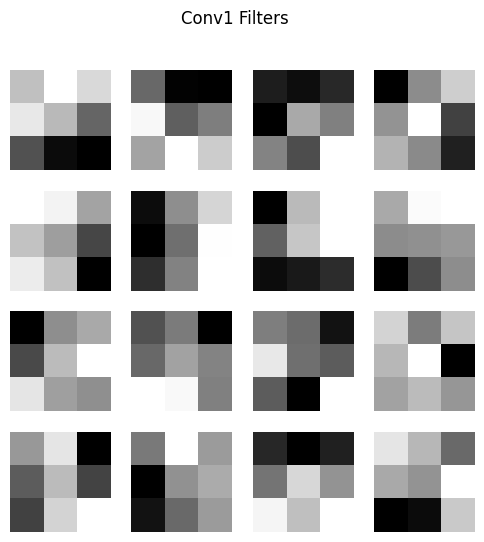

In [12]:
filters = cnn.layers[0].get_weights()[0]
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    f = filters[:,:,0,i]
    ax.imshow(f, cmap='gray')
    ax.axis('off')
plt.suptitle("Conv1 Filters")
plt.show()

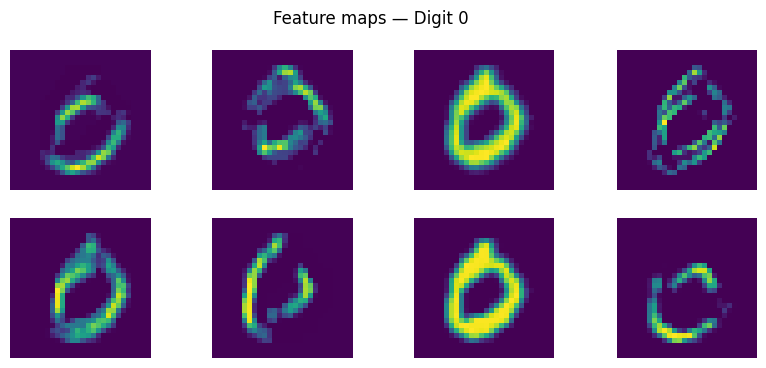

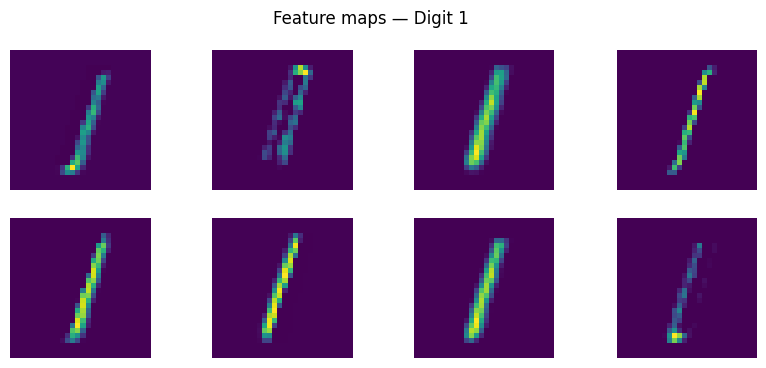

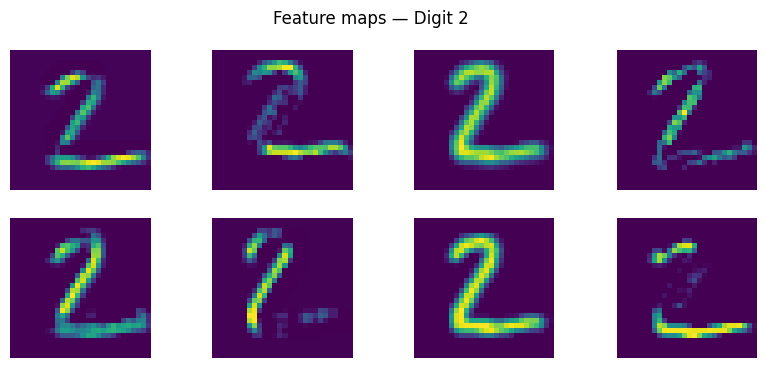

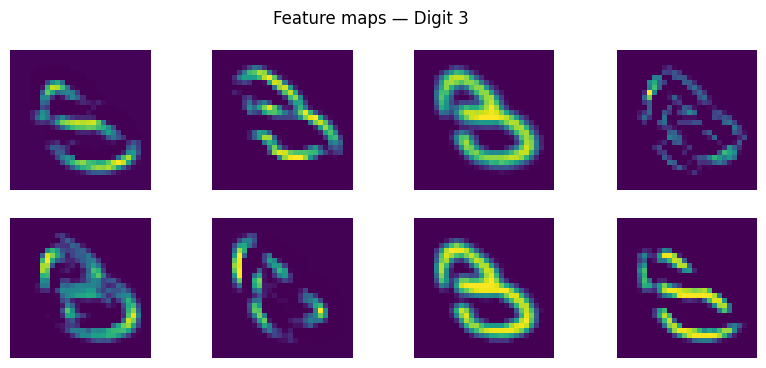

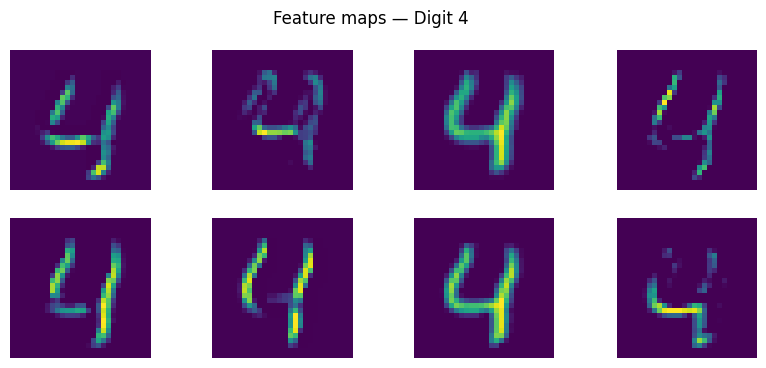

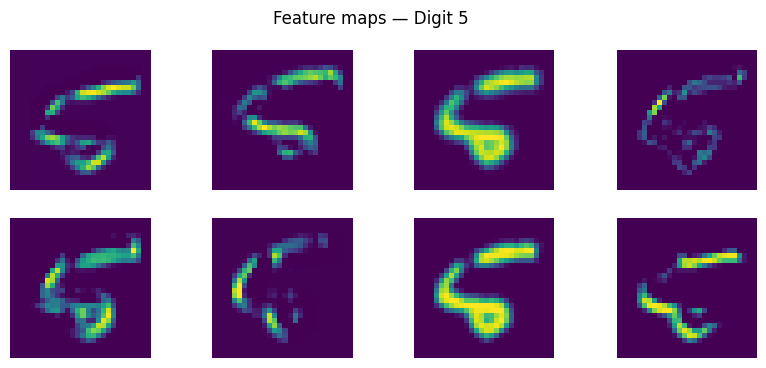

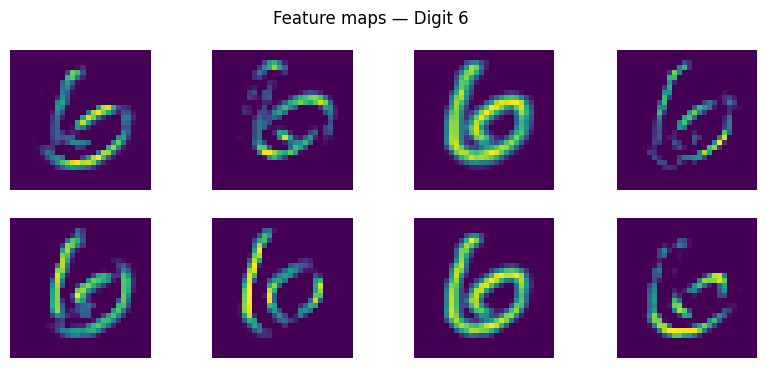

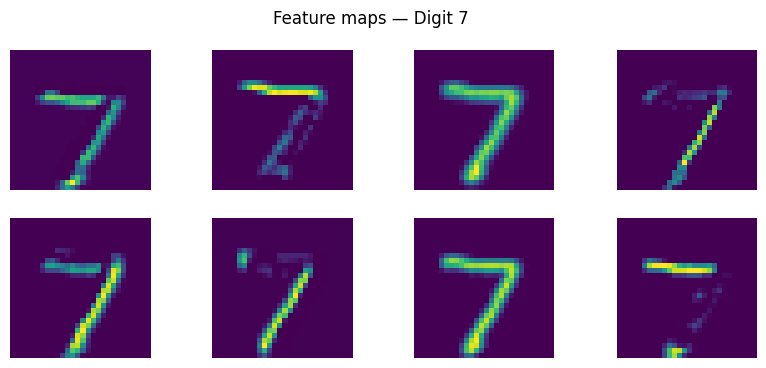

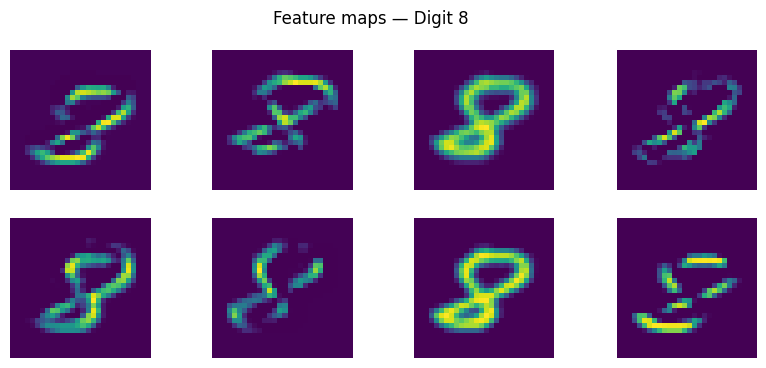

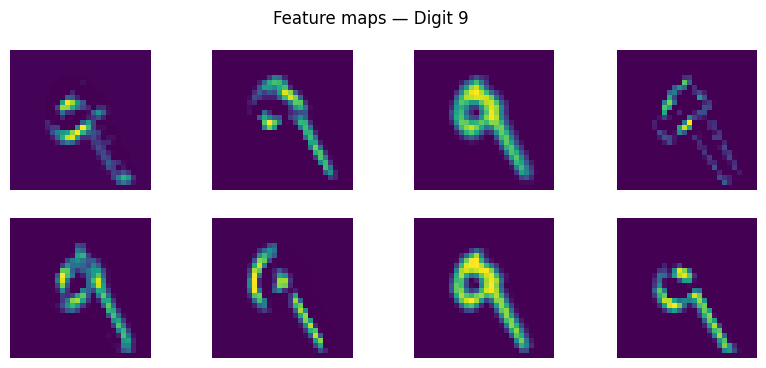

In [16]:
feature_map_model = Model(inputs=cnn.inputs,
                          outputs=cnn.layers[0].output)

for digit in range(10):
    index = np.where(y_test_c == digit)[0][0]
    image = X_test_c[index:index+1]

    feature_maps = feature_map_model.predict(image, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(10, 4))
    fig.suptitle(f"Feature maps — Digit {digit}")

    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.axis('off')

    plt.show()

In [17]:
cnn.save("cnn_mnist.h5")
print("CNN saved.")

CNN saved.
